In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import os
import sys

current_dir = os.getcwd()
snowflake_path = os.path.join(os.path.dirname(current_dir), 'SnowflakeETL')
sys.path.append(snowflake_path)
import SnowflakeETL

#import Pipeline
import os, sys
current_dir = os.getcwd()
base_path = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(os.path.join(base_path, 'ProficiencyModelTrainingPipeline'))
print(sys.path)

from ProficiencyModelTrainingPipeline import PercentileRankCalculator

# Main execution
# First get the live data
query = """
SELECT * FROM PROGRESS.ELA_PROFICIENCY_EVENTS 
WHERE OCCURREDAT >= '2024-12-28'
AND METADATA:sagemakerResponse:modelVersion[0]= '3.9c14c'
ORDER BY OCCURREDAT DESC"""

column_names, live_data = SnowflakeETL.run_snowflake_query(query)
print(f"Fetched {len(live_data)} predictions")


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
2025-01-03 07:54:50,364 - Snowflake Connector for Python Version: 3.12.4, Python Version: 3.10.15, Platform: Linux-5.10.228-219.884.amzn2.x86_64-x86_64-with-glibc2.26
2025-01-03 07:54:50,364 - Connecting to GLOBAL Snowflake domain
2025-01-03 07:54:50,365 - This connection is in OCSP Fail Open Mode. TLS Certificates would be checked for validity and revocation status. Any othe

['/home/ec2-user/anaconda3/envs/python3/lib/python310.zip', '/home/ec2-user/anaconda3/envs/python3/lib/python3.10', '/home/ec2-user/anaconda3/envs/python3/lib/python3.10/lib-dynload', '', '/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages', '/home/ec2-user/SageMaker/[REDACTED]AppliedScience/Omar/SnowflakeETL', '/home/ec2-user/SageMaker/[REDACTED]AppliedScience/Omar/ProficiencyModelTrainingPipeline']


2025-01-03 07:54:50,770 - Number of results in first chunk: 1
2025-01-03 07:54:50,844 - Number of results in first chunk: 1
2025-01-03 07:54:56,631 - Number of results in first chunk: 79
2025-01-03 07:54:59,540 - closed
2025-01-03 07:54:59,556 - No async queries seem to be running, deleting session


Fetched 277285 predictions


In [2]:
import os
import shutil

test_dir = "test_inference_comparison_temp"
os.makedirs(test_dir, exist_ok=True)
print(f"Created temp directory: {test_dir}")

# Source container directory
container_dir = "../ModelImplementationWSDK/ELA_student_proficiency_model_v0/container/"

# Copy all contents of container directory
for item in os.listdir(container_dir):
    src = os.path.join(container_dir, item)
    dst = os.path.join(test_dir, item)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        print(f"Copied {item}")

print("\nContents of temp directory:")
print(os.listdir(test_dir))

# Change to temp directory before loading
os.chdir(test_dir)
print("\nCurrent working directory:", os.getcwd())


Created temp directory: test_inference_comparison_temp
Copied proficiency_model.json
Copied confidence_model.json
Copied Dockerfile
Copied inference.py
Copied build_and_push.sh
Copied item_params.csv
Copied confidence_score_scaler.json

Contents of temp directory:
['proficiency_model.json', 'confidence_model.json', '__pycache__', 'Dockerfile', 'inference.py', 'test_inference_comparison_temp', 'build_and_push.sh', 'item_params.csv', 'confidence_score_scaler.json']

Current working directory: /home/ec2-user/SageMaker/[REDACTED]AppliedScience/Omar/WithinSkill_ELA_v2/test_inference_comparison_temp


In [3]:
import os
current_dir = os.getcwd()
print(current_dir)


/home/ec2-user/SageMaker/[REDACTED]AppliedScience/Omar/WithinSkill_ELA_v2/test_inference_comparison_temp


In [4]:
import os
import shutil
import tempfile

import importlib.util

# Now load inference using the copied files
inference_path = os.path.join(current_dir, 'inference.py')
spec = importlib.util.spec_from_file_location("inference", inference_path)
inference_load = importlib.util.module_from_spec(spec)
spec.loader.exec_module(inference_load)

# Create test client
app = inference_load.app
client = app.test_client()


All models, artifacts, and IP data loaded successfully.


In [23]:
DIVIDE_BY_HUNDRED=True

# Process predictions
predictions = []
for idx, row in enumerate(live_data[:1000]):
    if idx % 10 == 0:
        print(f"Processing row {idx}/{len(live_data)}")
    
    # Parse the metadata JSON 
    metadata = json.loads(row[1])
    
    if DIVIDE_BY_HUNDRED:
        # Get the correctness history and divide by 100
        correctness_history = metadata.get('sagemakerInput', {}).get('correctnessHistory', [])
        correctness_history = [x/100 for x in correctness_history]
    else:
        correctness_history = metadata.get('sagemakerInput', {}).get('correctnessHistory', [])
    
    # Extract input data from metadata JSON
    input_data = {
        'skillId': metadata.get('sagemakerInput', {}).get('skillId'),  # Changed from row[2]
        'questionId': metadata.get('sagemakerInput', {}).get('questionId'),
        'eventTime': metadata.get('sagemakerInput', {}).get('eventTime'),  # Changed from row[0]
        'questionIdsHistory': metadata.get('sagemakerInput', {}).get('questionIdsHistory', []),
        'correctnessHistory': correctness_history,
        'durationSecondsHistory': metadata.get('sagemakerInput', {}).get('durationSecondsHistory', []),
        'eventTimesHistory': metadata.get('sagemakerInput', {}).get('eventTimesHistory', [])
    }
    
    # Get local prediction through Flask 
    response = client.post('/invocations', 
                         json=input_data,
                         content_type='application/json')
    
    if response.status_code != 200:
        print(f"Error on row {idx}: {response.get_json()}")
        continue
        
    local_pred = response.get_json()
    
    predictions.append({
        'local_prof': local_pred['prediction']['item_prediction'][0],
        'live_prof': metadata['sagemakerResponse']['itemPrediction'][0],
        'local_conf': local_pred['prediction']['item_prediction_confidence'][0],
        'live_conf': metadata['sagemakerResponse']['itemPredictionConfidence'][0],
        'local_error': local_pred['prediction']['item_prediction_error'][0],
        'live_error': metadata['sagemakerResponse']['itemPredictionError'][0],
        'num_history': len(metadata.get('sagemakerInput', {}).get('questionIdsHistory', [])),
        'skill_id': metadata.get('sagemakerInput', {}).get('skillId')  # Changed from row[2]
    })
    
    if idx % 100 == 0:
        print(f"\nProcessed {idx} rows. Sample prediction comparison:")
        print(f"Local proficiency: {predictions[-1]['local_prof']:.4f}")
        print(f"Live proficiency: {predictions[-1]['live_prof']:.4f}")
        print(f"Local confidence: {predictions[-1]['local_conf']:.4f}")
        print(f"Live confidence: {predictions[-1]['live_conf']:.4f}")
        print(f"Local error: {predictions[-1]['local_error']:.4f}")
        print(f"Live error: {predictions[-1]['live_error']:.4f}")

Processing row 0/277285

Processed 0 rows. Sample prediction comparison:
Local proficiency: 0.2479
Live proficiency: 0.2479
Local confidence: 0.0146
Live confidence: 0.0146
Local error: 0.3619
Live error: 0.3619
Processing row 10/277285
Processing row 20/277285
Processing row 30/277285
Processing row 40/277285
Processing row 50/277285
Processing row 60/277285
Processing row 70/277285
Processing row 80/277285
Processing row 90/277285
Processing row 100/277285

Processed 100 rows. Sample prediction comparison:
Local proficiency: 0.4644
Live proficiency: 0.4644
Local confidence: 4.8382
Live confidence: 4.8382
Local error: 0.2917
Live error: 0.2917
Processing row 110/277285
Processing row 120/277285
Processing row 130/277285
Processing row 140/277285
Processing row 150/277285
Processing row 160/277285
Processing row 170/277285
Processing row 180/277285
Processing row 190/277285
Processing row 200/277285

Processed 200 rows. Sample prediction comparison:
Local proficiency: 0.3658
Live profi

2025-01-03 08:44:48,545 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-01-03 08:44:48,551 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


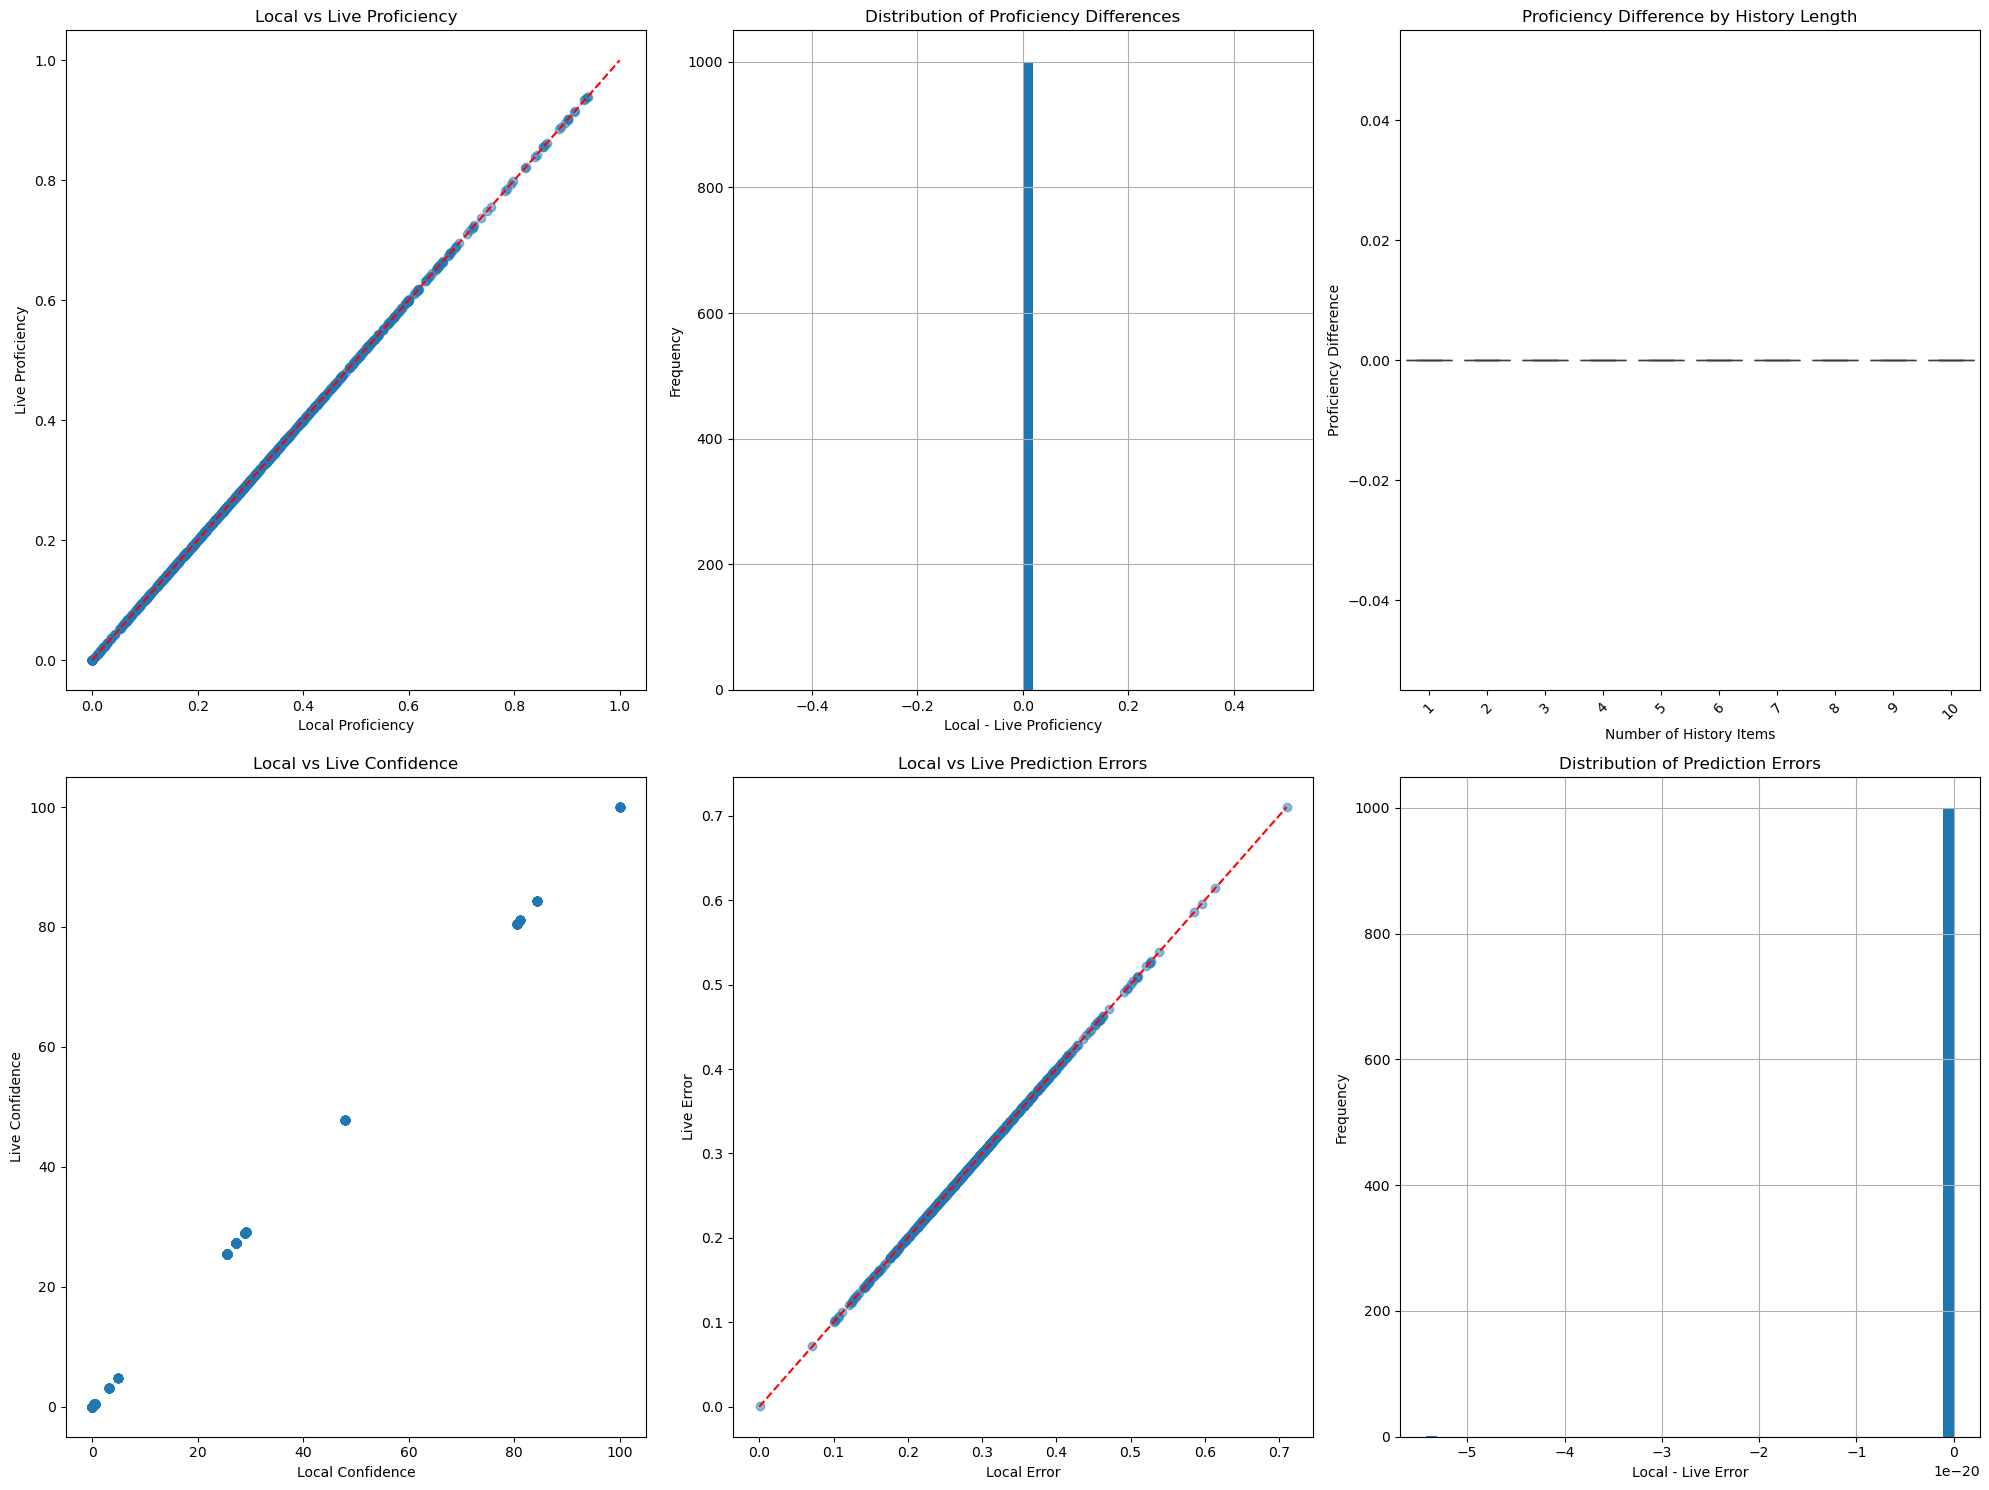


Summary Statistics:
        local_prof    live_prof   local_conf    live_conf  local_error  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.309160     0.309160    23.375663    23.375663     0.283263   
std       0.193651     0.193651    25.876652    25.876652     0.069633   
min       0.000000     0.000000     0.001219     0.001219     0.000335   
25%       0.173484     0.173484     0.394852     0.394852     0.244272   
50%       0.282193     0.282193    25.535000    25.535000     0.278002   
75%       0.423634     0.423634    29.030175    29.030175     0.310786   
max       0.939429     0.939429    99.998781    99.998781     0.710266   

        live_error  prof_diff    error_diff  
count  1000.000000     1000.0  1.000000e+03  
mean      0.283263        0.0 -5.421011e-23  
std       0.069633        0.0  1.714274e-21  
min       0.000335        0.0 -5.421011e-20  
25%       0.244272        0.0  0.000000e+00  
50%       0.278002        0.0  0.000

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert predictions to DataFrame 
predictions_df = pd.DataFrame(predictions) 

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a figure with multiple subplots 
plt.figure(figsize=(20, 15)) 

# 1. Scatter plot of local vs live proficiency 
plt.subplot(2, 3, 1) 
plt.scatter(predictions_df['local_prof'], predictions_df['live_prof'], alpha=0.5) 
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line 
plt.xlabel('Local Proficiency') 
plt.ylabel('Live Proficiency') 
plt.title('Local vs Live Proficiency') 

# 2. Histogram of proficiency differences 
plt.subplot(2, 3, 2) 
predictions_df['prof_diff'] = predictions_df['local_prof'] - predictions_df['live_prof'] 
predictions_df['prof_diff'].hist(bins=50) 
plt.xlabel('Local - Live Proficiency') 
plt.ylabel('Frequency') 
plt.title('Distribution of Proficiency Differences') 

# 3. Boxplot of differences 
plt.subplot(2, 3, 3) 
sns.boxplot(x='num_history', y='prof_diff', data=predictions_df, 
            order=sorted(predictions_df['num_history'].unique()))
plt.xlabel('Number of History Items') 
plt.ylabel('Proficiency Difference') 
plt.title('Proficiency Difference by History Length') 
plt.xticks(rotation=45)

# 4. Confidence comparison 
plt.subplot(2, 3, 4) 
plt.scatter(predictions_df['local_conf'], predictions_df['live_conf'], alpha=0.5) 
plt.xlabel('Local Confidence') 
plt.ylabel('Live Confidence') 
plt.title('Local vs Live Confidence') 

# 5. Error comparison 
plt.subplot(2, 3, 5) 
plt.scatter(predictions_df['local_error'], predictions_df['live_error'], alpha=0.5) 
plt.plot([0, max(predictions_df['local_error'].max(), predictions_df['live_error'].max())],
         [0, max(predictions_df['local_error'].max(), predictions_df['live_error'].max())], 'r--') 
plt.xlabel('Local Error') 
plt.ylabel('Live Error') 
plt.title('Local vs Live Prediction Errors') 

# 6. Histogram of error differences 
plt.subplot(2, 3, 6) 
predictions_df['error_diff'] = predictions_df['local_error'] - predictions_df['live_error'] 
predictions_df['error_diff'].hist(bins=50) 
plt.xlabel('Local - Live Error') 
plt.ylabel('Frequency') 
plt.title('Distribution of Prediction Errors') 

plt.tight_layout() 
plt.show()

# Print some summary statistics
print("\nSummary Statistics:")
print(predictions_df[['local_prof', 'live_prof', 'local_conf', 'live_conf', 'local_error', 'live_error', 'prof_diff', 'error_diff']].describe())

# Correlation analysis
print("\nCorrelation Matrix:")
print(predictions_df[['local_prof', 'live_prof', 'local_conf', 'live_conf', 'local_error', 'live_error']].corr())

In [25]:
local_pred

{'debug_info': {'feature_engineered_input': {'CORRECTNESS_LAG_1': 0.01,
   'CORRECTNESS_LAG_10': None,
   'CORRECTNESS_LAG_2': None,
   'CORRECTNESS_LAG_3': None,
   'CORRECTNESS_LAG_4': None,
   'CORRECTNESS_LAG_5': None,
   'CORRECTNESS_LAG_6': None,
   'CORRECTNESS_LAG_7': None,
   'CORRECTNESS_LAG_8': None,
   'CORRECTNESS_LAG_9': None,
   'DURATIONSECONDS_LAG_1': None,
   'DURATIONSECONDS_LAG_10': None,
   'DURATIONSECONDS_LAG_2': None,
   'DURATIONSECONDS_LAG_3': None,
   'DURATIONSECONDS_LAG_4': None,
   'DURATIONSECONDS_LAG_5': None,
   'DURATIONSECONDS_LAG_6': None,
   'DURATIONSECONDS_LAG_7': None,
   'DURATIONSECONDS_LAG_8': None,
   'DURATIONSECONDS_LAG_9': None,
   'LOG_DURATIONSECONDS_LAG_1': None,
   'LOG_DURATIONSECONDS_LAG_10': None,
   'LOG_DURATIONSECONDS_LAG_2': None,
   'LOG_DURATIONSECONDS_LAG_3': None,
   'LOG_DURATIONSECONDS_LAG_4': None,
   'LOG_DURATIONSECONDS_LAG_5': None,
   'LOG_DURATIONSECONDS_LAG_6': None,
   'LOG_DURATIONSECONDS_LAG_7': None,
   'LOG_DUR

In [26]:
input_data

{'skillId': 'dgizuvmj',
 'questionId': '81994ae5-0eab-48b5-8f2d-55a7c718eabb',
 'eventTime': '2025-01-02T17:36:14.499956325Z',
 'questionIdsHistory': ['81994ae5-0eab-48b5-8f2d-55a7c718eabb',
  '24bfd59a-d585-4690-9836-b7ffe5343950'],
 'correctnessHistory': [0.01, 0.01],
 'durationSecondsHistory': [None, None],
 'eventTimesHistory': ['2025-01-02T17:36:14.499956325Z',
  '2025-01-02T17:33:36.23041565Z']}

In [27]:
live_data[99]

(50511204,
 '{\n  "answerToken": "ProductElaAdaptiveSkillsPractice:1055455823",\n  "numQuestionsAnswered": 6,\n  "product": "ela_adaptive_skills_practice",\n  "questionId": "a31fe5dd-6a42-4397-8e99-c89aea3fe525",\n  "sagemakerInput": {\n    "correctnessHistory": [\n      1,\n      1,\n      0,\n      1,\n      1,\n      1\n    ],\n    "durationSecondsHistory": [\n      5,\n      3,\n      2,\n      4,\n      2,\n      3\n    ],\n    "eventTime": "2025-01-02T17:37:15.080849809Z",\n    "eventTimesHistory": [\n      "2025-01-02T17:37:15.080849809Z",\n      "2025-01-02T17:37:09.285645025Z",\n      "2025-01-02T17:37:03.62810368Z",\n      "2025-01-02T17:37:00.629994491Z",\n      "2025-01-02T17:36:55.544394131Z",\n      "2025-01-02T17:36:52.603733662Z"\n    ],\n    "questionId": "a31fe5dd-6a42-4397-8e99-c89aea3fe525",\n    "questionIdsHistory": [\n      "a31fe5dd-6a42-4397-8e99-c89aea3fe525",\n      "7f041e59-7e6e-47d8-a967-708e99142dee",\n      "7e565ace-605b-4938-8667-6c9c3455974b",\n      